**JERIC J. DELA CRUZ**

**FRANZ HARRY DANIEL A. EDA** 

BSIT 3-2

In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-socmed-addiction/Students Social Media Addiction.csv


In [25]:
file_path = '/kaggle/input/students-socmed-addiction/Students Social Media Addiction.csv'
df = pd.read_csv(file_path)
df.head()


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [26]:
# Remove exact duplicate rows
df_clean = df.drop_duplicates()

# Optional: reset index after dropping duplicates
df_clean.reset_index(drop=True, inplace=True)

In [27]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


**Distribution of Average Daily Social Media Usage**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


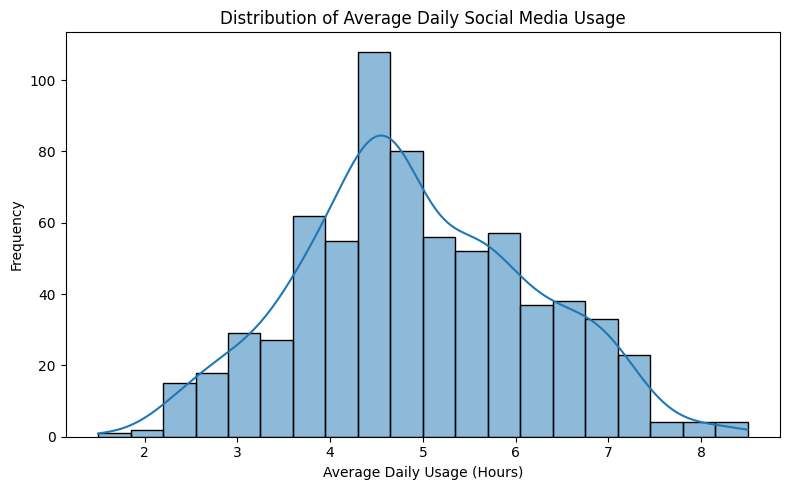

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Avg_Daily_Usage_Hours'], bins=20, kde=True)
plt.title("Distribution of Average Daily Social Media Usage")
plt.xlabel("Average Daily Usage (Hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Addiction Score by Academic Level**

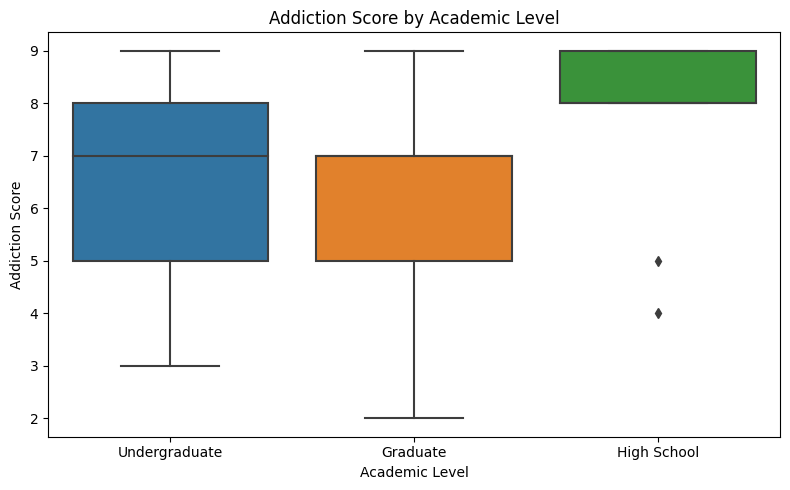

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Academic_Level', y='Addicted_Score', data=df)
plt.title("Addiction Score by Academic Level")
plt.ylabel("Addiction Score")
plt.xlabel("Academic Level")
plt.tight_layout()
plt.show()

**Most Used Social Media Platforms**

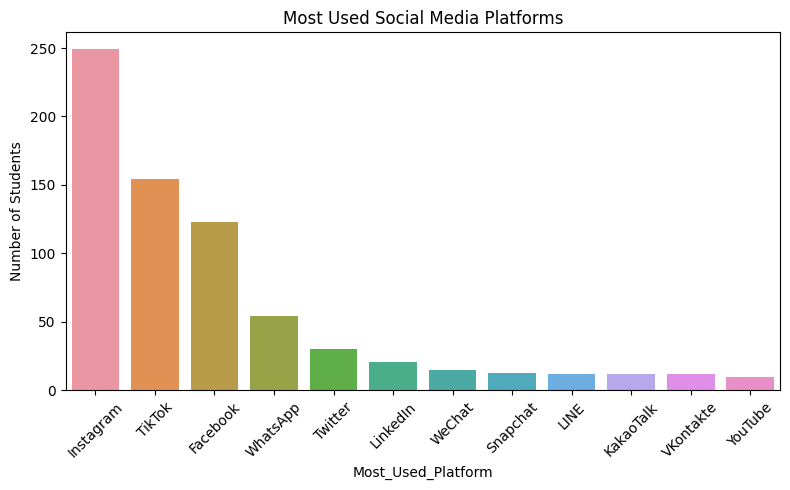

In [30]:
plt.figure(figsize=(8, 5))
platform_counts = df['Most_Used_Platform'].value_counts()
sns.barplot(x=platform_counts.index, y=platform_counts.values)
plt.title("Most Used Social Media Platforms")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Gender distribution**

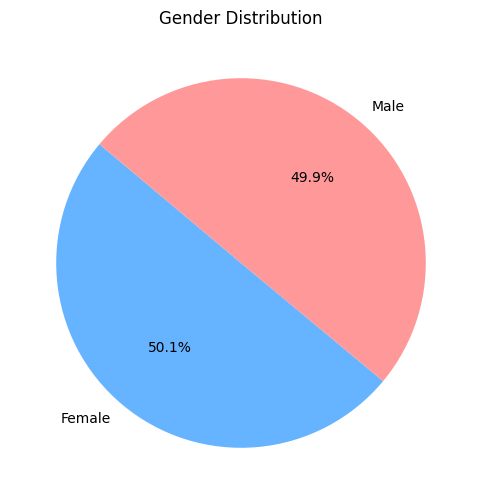

In [31]:
gender_counts = df_clean['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Gender Distribution')
plt.show()

**Average Daily Usage Hours by Academic Level**

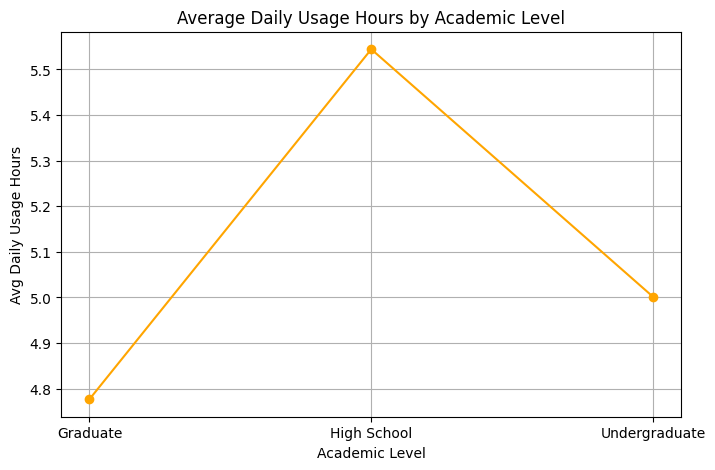

In [32]:
avg_usage_by_level = df_clean.groupby('Academic_Level')['Avg_Daily_Usage_Hours'].mean().sort_index()

plt.figure(figsize=(8,5))
plt.plot(avg_usage_by_level.index, avg_usage_by_level.values, marker='o', linestyle='-', color='orange')
plt.title('Average Daily Usage Hours by Academic Level')
plt.xlabel('Academic Level')
plt.ylabel('Avg Daily Usage Hours')
plt.grid(True)
plt.show()


**Average Sleep Hours Per Night by Gender**

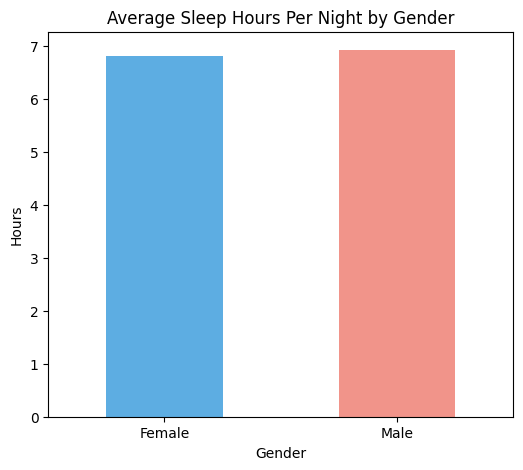

In [33]:
sleep_by_gender = df_clean.groupby('Gender')['Sleep_Hours_Per_Night'].mean()

plt.figure(figsize=(6,5))
sleep_by_gender.plot(kind='bar', color=['#5DADE2', '#F1948A'])
plt.title('Average Sleep Hours Per Night by Gender')
plt.ylabel('Hours')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.show()


**Mental Health Score distribution by Age groups**

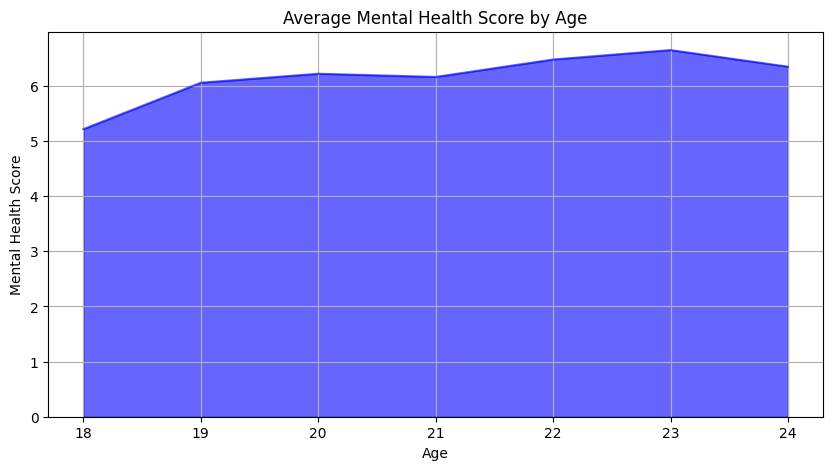

In [35]:
mental_health_by_age = df_clean.groupby('Age')['Mental_Health_Score'].mean()

plt.figure(figsize=(10,5))
mental_health_by_age.plot(kind='area', color='blue', alpha=0.6)
plt.title('Average Mental Health Score by Age')
plt.xlabel('Age')
plt.ylabel('Mental Health Score')
plt.grid(True)
plt.show()


**Country-wise student count (Top 10 countries)**

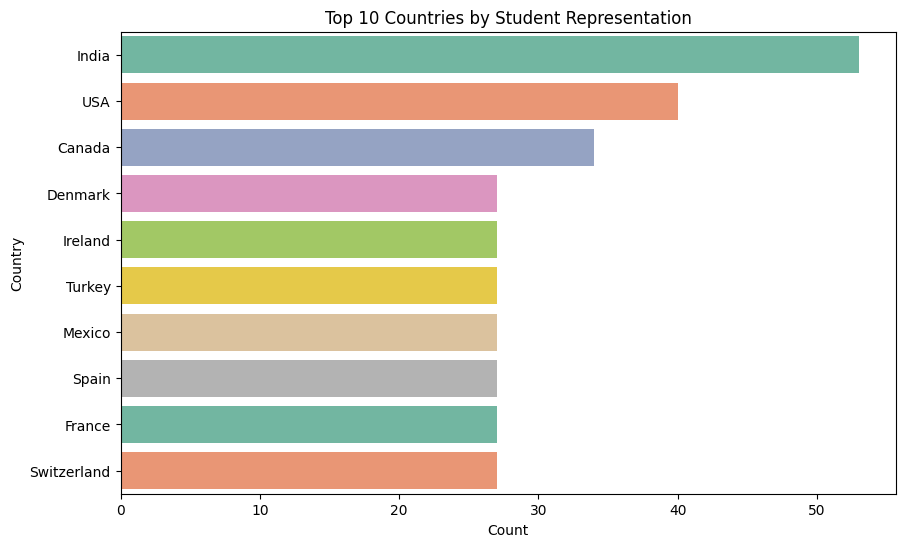

In [36]:
top_countries = df_clean['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.countplot(data=df_clean[df_clean['Country'].isin(top_countries.index)],
              y='Country', order=top_countries.index, palette='Set2')
plt.title('Top 10 Countries by Student Representation')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()


**Sleep Hours vs Usage Hours (Clustered by Gender)**

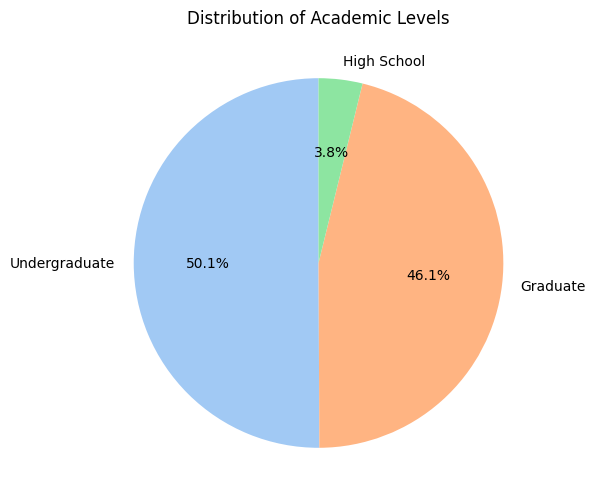

In [38]:
plt.figure(figsize=(6,6))
df_clean['Academic_Level'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Academic Levels')
plt.ylabel('')
plt.show()


**Top 5 Most Used Platforms (Sorted)**

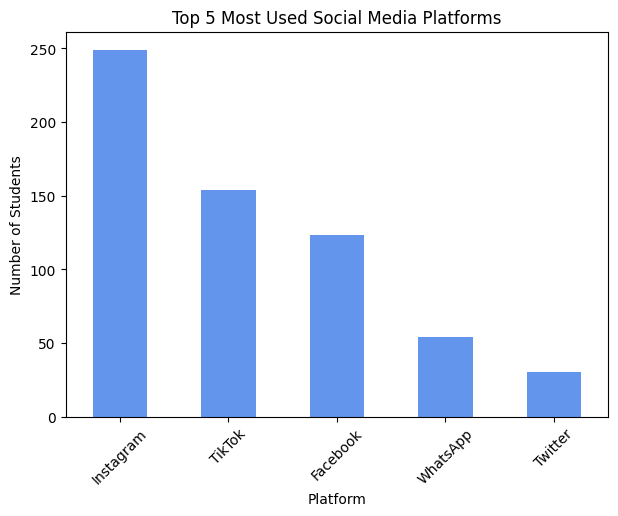

In [40]:
top_platforms = df_clean['Most_Used_Platform'].value_counts().head(5)

top_platforms.plot(kind='bar', color='cornflowerblue', figsize=(7,5))
plt.title('Top 5 Most Used Social Media Platforms')
plt.xlabel('Platform')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.show()


**Average Daily Usage by Country (Top 10 only)**

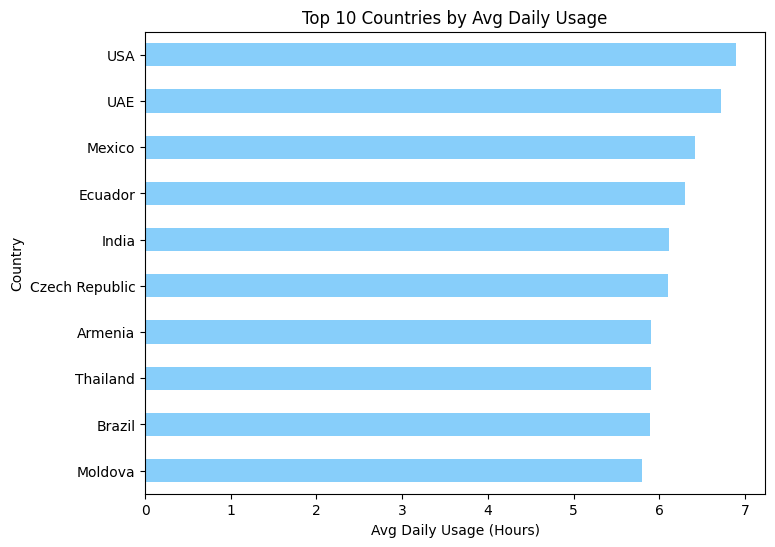

In [41]:
avg_usage_country = df_clean.groupby('Country')['Avg_Daily_Usage_Hours'].mean().sort_values(ascending=False).head(10)

avg_usage_country.plot(kind='barh', color='lightskyblue', figsize=(8,6))
plt.title('Top 10 Countries by Avg Daily Usage')
plt.xlabel('Avg Daily Usage (Hours)')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.show()


**Gender Split over Most Used Platforms**

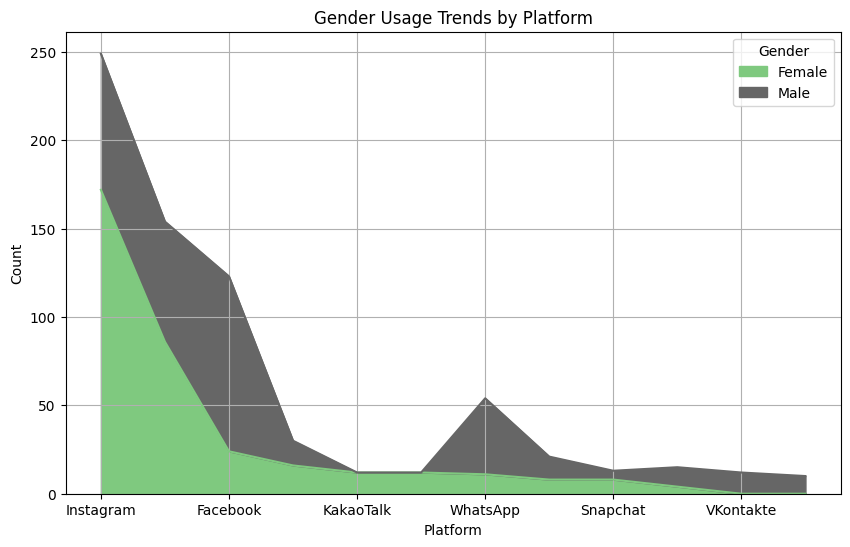

In [42]:
gender_platform = pd.crosstab(df_clean['Most_Used_Platform'], df_clean['Gender'])

gender_platform.sort_values(by='Female', ascending=False).plot(kind='area', stacked=True, figsize=(10,6), cmap='Accent')
plt.title('Gender Usage Trends by Platform')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.grid(True)
plt.show()


**Counts of relationship status**

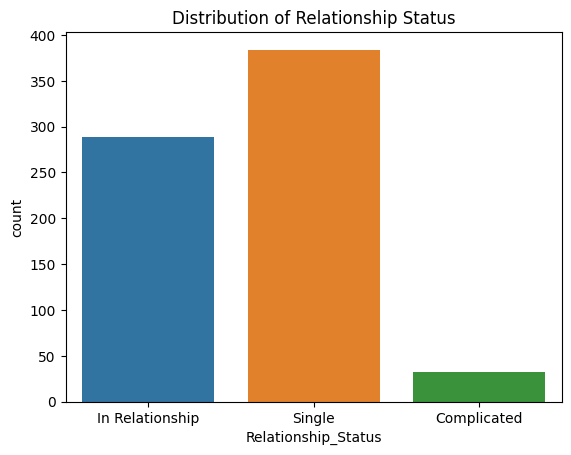

In [43]:
sns.countplot(data=df, x='Relationship_Status')
plt.title('Distribution of Relationship Status')
plt.show()

**Relationship status by addiction level bins**

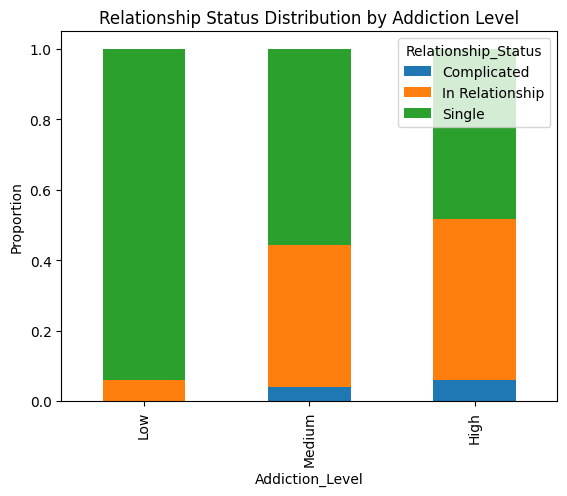

In [46]:
df['Addiction_Level'] = pd.cut(df['Addicted_Score'], bins=[0,3,7,10], labels=['Low','Medium','High'])
cross_tab = pd.crosstab(df['Addiction_Level'], df['Relationship_Status'], normalize='index')
cross_tab.plot(kind='bar', stacked=True)
plt.title('Relationship Status Distribution by Addiction Level')
plt.ylabel('Proportion')
plt.show()